In [1]:
from google.colab import drive
import os
import zipfile

from PIL import Image
from collections import Counter
import hashlib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

## Inspect BUSI Dataset

In [2]:
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Breast_Ultrasonic/BUSI.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    files = zip_ref.namelist()

print(f"Number of files: {len(files)}")
print("\n".join(files[:10]))
print("...")
print("\n".join(files[-10:]))

Mounted at /content/drive
Number of files: 1261
BUSI/
BUSI/images/
BUSI/images/benign_1.png
BUSI/images/benign_10.png
BUSI/images/benign_101.png
BUSI/images/benign_102.png
BUSI/images/benign_103.png
BUSI/images/benign_104.png
BUSI/images/benign_105.png
BUSI/images/benign_106.png
...
BUSI/labels/malignant_90.png
BUSI/labels/malignant_91.png
BUSI/labels/malignant_92.png
BUSI/labels/malignant_93.png
BUSI/labels/malignant_94.png
BUSI/labels/malignant_95.png
BUSI/labels/malignant_96.png
BUSI/labels/malignant_97.png
BUSI/labels/malignant_98.png
BUSI/labels/malignant_99.png


In [3]:
DATASET_DIR = '/content/drive/MyDrive/Breast_Ultrasonic'
BUSI_DIR = os.path.join(DATASET_DIR, 'BUSI')

if os.path.exists(BUSI_DIR):
    print("Dataset already exists.")
    print("Skipping extraction.")
else:
    os.makedirs(DATASET_DIR, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)

    print("Extraction complete.")

Dataset already exists.
Skipping extraction.


In [4]:
dataset_dir = os.path.join(DATASET_DIR, "BUSI")
image_dir = os.path.join(dataset_dir, 'images')
label_dir = os.path.join(dataset_dir, 'labels')

image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(".png")]
label_files = [f for f in os.listdir(label_dir) if f.lower().endswith(".png")]

print(f"Total images: {len(image_files)}")
print(f"Total images: {len(label_files)}")

Total images: 629
Total images: 629


In [5]:
benign_images = [f for f in image_files if f.startswith("benign_")]
malignant_images = [f for f in image_files if f.startswith("malignant_")]

benign_labels = [f for f in label_files if f.startswith("benign_")]
malignant_labels = [f for f in label_files if f.startswith("malignant_")]

print(f"Benign image: {len(benign_images)} files")
print(f"Malignant image: {len(malignant_images)} files\n")

print(f"Benign label: {len(benign_labels)} files")
print(f"Malignant label: {len(malignant_labels)} files")

Benign image: 420 files
Malignant image: 209 files

Benign label: 420 files
Malignant label: 209 files


### Check PNG Dimensions

In [6]:
image_sizes = []
label_sizes = []

for filename in image_files:
    image_path = os.path.join(image_dir, filename)
    label_path = os.path.join(label_dir, filename)

    with Image.open(image_path) as img:
       image_sizes.append(img.size)

    with Image.open(label_path) as lbl:
       label_sizes.append(lbl.size)

image_size_counts = Counter(image_sizes)
label_size_counts = Counter(label_sizes)

print("Different image dimensions: ")
print(f"Unique Image Size: {len(image_size_counts)}")
print(f"Unique Label Size: {len(label_size_counts)}")

Different image dimensions: 
Unique Image Size: 530
Unique Label Size: 530


### Check Corresponding Masks

In [7]:
image_names = set(image_files)
label_names = set(label_files)

images_without_labels = image_names - label_names
labels_without_images = label_names - image_names

print(f"Images without labels: {len(images_without_labels)}")
print(f"Labels without images: {len(labels_without_images)}")

Images without labels: 0
Labels without images: 0


In [8]:
missing_labels = sorted(labels_without_images)

missing_benign = [f for f in missing_labels if f.startswith("benign_")]
missing_malignant = [f for f in missing_labels if f.startswith("malignant_")]
missing_normal = [f for f in missing_labels if f.startswith("normal_")]

print("Total:", len(missing_labels))
print("Benign:", len(missing_benign))
print("Malignant:", len(missing_malignant))

Total: 0
Benign: 0
Malignant: 0


### Check Duplicated Data

In [9]:
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}

for filename in label_files:
    path = os.path.join(label_dir, filename)
    h = file_hash(path)

    if h not in hashes:
        hashes[h] = []

duplicates = [files for files in hashes.values() if len(files) > 1]

print(f"Duplicate groups: {len(duplicates)}")

Duplicate groups: 0


### Check Problematic Images

In [10]:
problematic_images = []

for filename in label_files:
    path = os.path.join(label_dir, filename)

    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        problematic_images.append((filename, str(e)))

print(f"Problematic images: {len(problematic_images)}")

Problematic images: 0


### Show Images

(np.float64(-0.5), np.float64(682.5), np.float64(584.5), np.float64(-0.5))

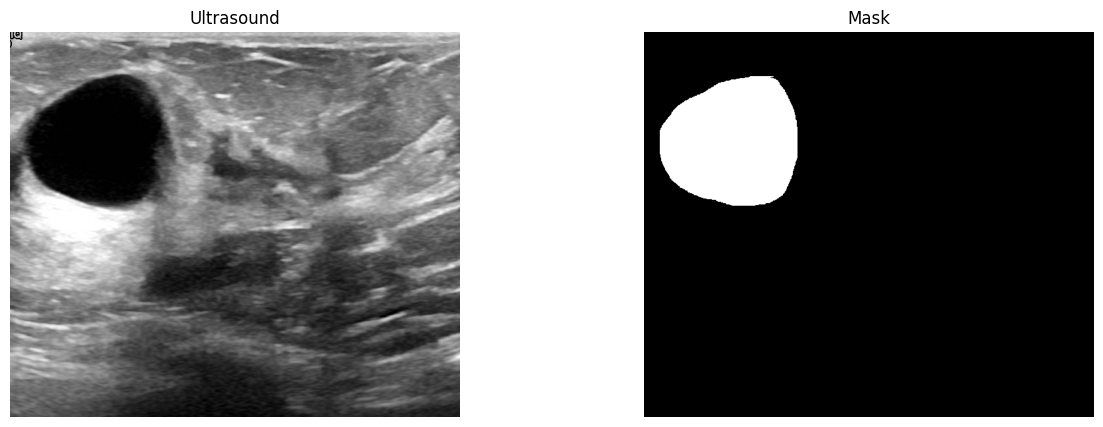

In [11]:
paired_files = []

for filename in image_files:
    if filename in label_files:
        paired_files.append(filename)

filename = paired_files[1]

image = np.array(
    Image.open(os.path.join(image_dir, filename)).convert("L")
)

mask = np.array(
    Image.open(os.path.join(label_dir, filename)).convert("L")
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Ultrasound")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

## Prepare for Training

In [12]:
records = []

for filename in image_files:
    if filename.startswith("benign_"):
        label = "benign"
    elif filename.startswith("malignant_"):
        label = "malignant"
    else:
        continue

    records.append({"filename": filename, "label": label, "has_mask": filename in label_names})

df = pd.DataFrame(records)
print(df.head())
print()
print(df["label"].value_counts())
print()
print(df["has_mask"].value_counts())

         filename   label  has_mask
0    benign_1.png  benign      True
1   benign_10.png  benign      True
2  benign_101.png  benign      True
3  benign_102.png  benign      True
4  benign_103.png  benign      True

label
benign       420
malignant    209
Name: count, dtype: int64

has_mask
True    629
Name: count, dtype: int64


In [13]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 440
Validation: 94
Test: 95


In [14]:
print("Train")
print(train_df['label'].value_counts())

print('\nValidation')
print(val_df['label'].value_counts())

print('\nTest')
print(test_df['label'].value_counts())

Train
label
benign       294
malignant    146
Name: count, dtype: int64

Validation
label
benign       63
malignant    31
Name: count, dtype: int64

Test
label
benign       63
malignant    32
Name: count, dtype: int64


## Preprocessing

In [15]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [16]:
label_map = {"benign": 0, "malignant": 1}

In [17]:
class BUSIDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        filename = row["filename"]
        label_name = row["label"]

        image_path = os.path.join(self.image_dir, filename)
        image = Image.open(image_path).convert("RGB")
        label = label_map[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
train_dataset = BUSIDataset(train_df, image_dir, transform=train_transform)
val_dataset = BUSIDataset(val_df, image_dir, transform=val_test_transform)
test_dataset = BUSIDataset(test_df, image_dir, transform=val_test_transform)

### DataLoaders

In [19]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [20]:
images, labels = next(iter(train_loader))

print(f"Image shape: {images.shape}")
print(f"Label shape: {labels.shape}")
print(f"Labels: {labels}")

Image shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Labels: tensor([0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 1])


In [21]:
print(f"Image min: {images.min().item()}")
print(f"Image max: {images.max().item()}")

Image min: -2.1179039478302
Image max: 2.640000104904175


### Visualize Transformed Images

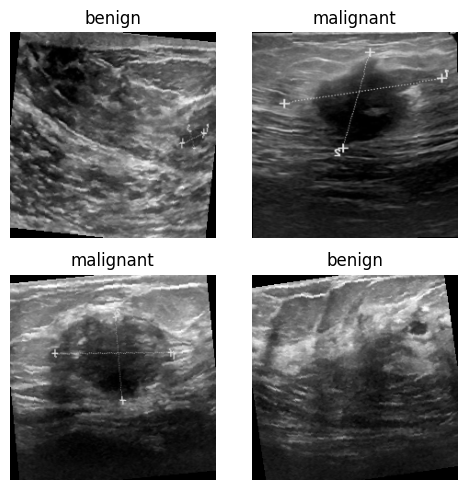

In [22]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

images_display = images * std + mean

plt.figure(figsize=(5, 5))

for i in range(4):
    plt.subplot(2, 2, i+1)

    image = images_display[i].permute(1, 2, 0)
    image = torch.clamp(image, 0, 1)

    plt.imshow(image)
    plt.title(list(label_map.keys())[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Classification with ResNet50

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [24]:
weights = models.ResNet50_Weights.DEFAULT

model = models.resnet50(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 125MB/s]


Linear(in_features=2048, out_features=2, bias=True)


### Lost Function

In [25]:
criterion = nn.CrossEntropyLoss()

## Optimizer

In [26]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

### Training Process

In [27]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [28]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [29]:
NUM_EPOCHS = 20
best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_resnet50_busi.pth")
        print(" -> Best model saved!")

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Acc: {train_acc:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

 -> Best model saved!
Epoch [1/20] Train Acc: 0.6250 Val Acc: 0.6702
Epoch [2/20] Train Acc: 0.7455 Val Acc: 0.6702
 -> Best model saved!
Epoch [3/20] Train Acc: 0.8364 Val Acc: 0.7872
 -> Best model saved!
Epoch [4/20] Train Acc: 0.8705 Val Acc: 0.8830
 -> Best model saved!
Epoch [5/20] Train Acc: 0.9136 Val Acc: 0.9362
Epoch [6/20] Train Acc: 0.9386 Val Acc: 0.9255
Epoch [7/20] Train Acc: 0.9705 Val Acc: 0.9149
Epoch [8/20] Train Acc: 0.9568 Val Acc: 0.9362
Epoch [9/20] Train Acc: 0.9659 Val Acc: 0.9362
 -> Best model saved!
Epoch [10/20] Train Acc: 0.9591 Val Acc: 0.9468
 -> Best model saved!
Epoch [11/20] Train Acc: 0.9818 Val Acc: 0.9574
Epoch [12/20] Train Acc: 0.9864 Val Acc: 0.9043
Epoch [13/20] Train Acc: 0.9886 Val Acc: 0.9468
Epoch [14/20] Train Acc: 0.9818 Val Acc: 0.9468
Epoch [15/20] Train Acc: 0.9841 Val Acc: 0.9468
Epoch [16/20] Train Acc: 0.9864 Val Acc: 0.9255
Epoch [17/20] Train Acc: 0.9773 Val Acc: 0.9574
Epoch [18/20] Train Acc: 0.9864 Val Acc: 0.9362
Epoch [19/20]

## Evaluate Trained ResNet50

### Load the Best Model

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model.load_state_dict(torch.load("/content/best_resnet50_busi.pth", map_location=device))
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Generate Predictions on Test Data

In [31]:
all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print(f"Label shape: {all_labels.shape}")
print(f"Predictions shape: {all_predictions.shape}")
print(f"Probabilities shape: {all_probabilities.shape}")

Label shape: (95,)
Predictions shape: (95,)
Probabilities shape: (95, 2)


### Calculate Classification Metrics

In [32]:
class_names = ["benign", "malignant"]

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average="weighted")
recall = recall_score(all_labels, all_predictions, average="weighted")
f1 = f1_score(all_labels, all_predictions, average="weighted")

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.9157894736842105
Precision: 0.9197676465411019
Recall: 0.9157894736842105
F1-score: 0.9133476324038937


In [33]:
print(classification_report(all_labels, all_predictions, target_names=class_names))

              precision    recall  f1-score   support

      benign       0.90      0.98      0.94        63
   malignant       0.96      0.78      0.86        32

    accuracy                           0.92        95
   macro avg       0.93      0.88      0.90        95
weighted avg       0.92      0.92      0.91        95



### Confusion Matrix

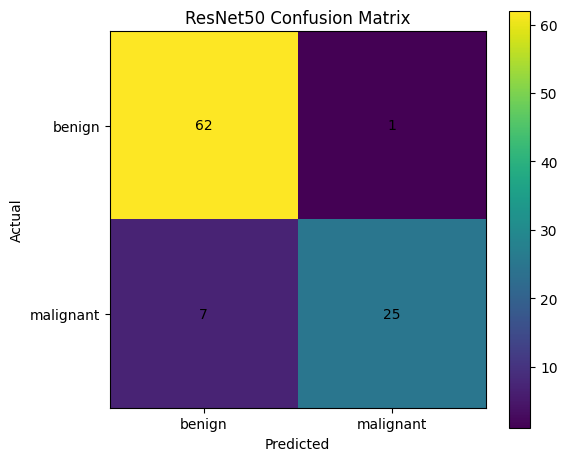

In [34]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

### Save Baseline Result

In [35]:
baseline_results = {
    "model": "ResNet50",
    "input": "full ultrasound image",
    "image_size": "224x224",
    "augmentation": "horizontal flip + rotation",
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "epochs": NUM_EPOCHS,
    "accuracy": accuracy,
    "precision_weighted": precision,
    "recall_weighted": recall,
    "f1_weighted": f1
}

baseline_results

{'model': 'ResNet50',
 'input': 'full ultrasound image',
 'image_size': '224x224',
 'augmentation': 'horizontal flip + rotation',
 'optimizer': 'AdamW',
 'learning_rate': 0.0001,
 'epochs': 20,
 'accuracy': 0.9157894736842105,
 'precision_weighted': 0.9197676465411019,
 'recall_weighted': 0.9157894736842105,
 'f1_weighted': 0.9133476324038937}

## U-Net Segmentation

### Preparing Segmentation Dataset

In [36]:
SEG_SIZE = 256

class BUSISegmentationDataset(Dataset):
    def __init__(self, dataframe, image_dir, label_dir):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.label_dir = label_dir

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        filename = row["filename"]

        image_path = os.path.join(self.image_dir, filename)
        mask_path = os.path.join(self.label_dir, filename)

        image = Image.open(image_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        image = image.resize((SEG_SIZE, SEG_SIZE), Image.BILINEAR)
        mask = mask.resize((SEG_SIZE, SEG_SIZE), Image.NEAREST)

        image = np.array(image)
        mask = np.array(mask)

        image = image.astype(np.float32) / 255.0
        mask = (mask > 0).astype(np.float32)

        image = torch.from_numpy(image).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask

In [37]:
SEG_BATCH_SIZE = 16

seg_train_dataset = BUSISegmentationDataset(train_df, image_dir, label_dir)
seg_val_dataset = BUSISegmentationDataset(val_df, image_dir, label_dir)
seg_test_dataset = BUSISegmentationDataset(test_df, image_dir, label_dir)

seg_train_loader = DataLoader(seg_train_dataset, batch_size=SEG_BATCH_SIZE, shuffle=True, num_workers=2)
seg_val_loader = DataLoader(seg_val_dataset, batch_size=SEG_BATCH_SIZE, shuffle=False, num_workers=2)
seg_test_loader = DataLoader(seg_test_dataset, batch_size=SEG_BATCH_SIZE, shuffle=False, num_workers=2)

In [38]:
images, masks = next(iter(seg_train_loader))

print(f"Images: {images.shape}")
print(f"Masks: {masks.shape}")

Images: torch.Size([16, 1, 256, 256])
Masks: torch.Size([16, 1, 256, 256])


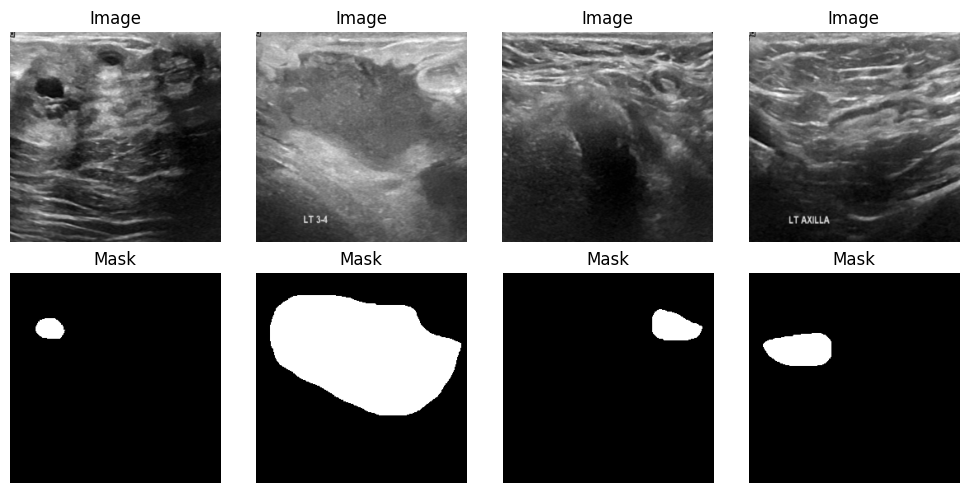

In [39]:
plt.figure(figsize=(10, 5))

for i in range(4):

    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i][0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2, 4, i + 5)
    plt.imshow(masks[i][0], cmap="gray")
    plt.title("Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

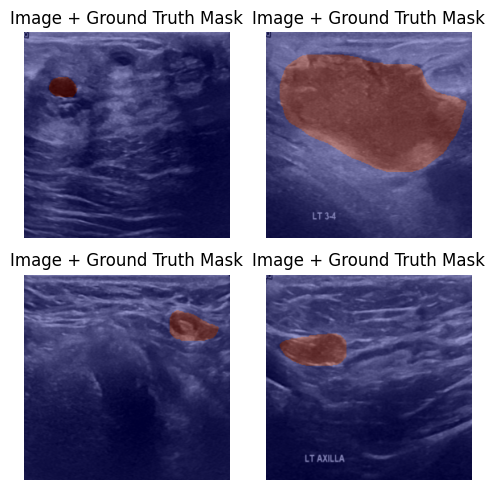

In [40]:
plt.figure(figsize=(5, 5))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.imshow(masks[i][0], cmap="jet", alpha=0.4)

    plt.title("Image + Ground Truth Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

### U-Net

In [41]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                                   nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                                   nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                                   nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.block(x)

In [42]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = UNet().to(device)

print(f"Device: {device}")

Device: cuda


### Dice Coefficient

In [44]:
def dice_coefficient(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()

    dice = (2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return dice

### Dice + BCE Loss

In [45]:
def dice_loss(pred, target):
    return 1 - dice_coefficient(pred, target)

bce_loss = nn.BCEWithLogitsLoss()

def segmentation_loss(pred, target):
    bce = bce_loss(pred, target)
    dice = dice_loss(pred, target)

    return bce + dice

### Optimizer

In [46]:
optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-4)

### Train U-Net

In [47]:
def train_segmentation_epoch(model, loader, optimizer, device):

    model.train()

    total_loss = 0
    total_dice = 0
    total_samples = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = segmentation_loss(outputs, masks)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        total_loss += (loss.item() * batch_size)
        total_dice += (dice_coefficient(outputs, masks).item() * batch_size)
        total_samples += batch_size

    return (total_loss / total_samples, total_dice / total_samples)

In [48]:
def validate_segmentation(model, loader, device):

    model.eval()

    total_loss = 0
    total_dice = 0
    total_samples = 0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = segmentation_loss(outputs, masks)

            batch_size = images.size(0)

            total_loss += (loss.item() * batch_size)
            total_dice += (dice_coefficient(outputs, masks).item() * batch_size)
            total_samples += batch_size

    return (total_loss / total_samples, total_dice / total_samples)

In [49]:
NUM_EPOCHS = 20

seg_history = {
    "train_loss": [],
    "train_dice": [],
    "val_loss": [],
    "val_dice": []
}

best_val_dice = 0.0

for epoch in range(NUM_EPOCHS):

    train_loss, train_dice = train_segmentation_epoch(unet, seg_train_loader, optimizer, device)
    val_loss, val_dice = validate_segmentation(unet, seg_val_loader, device)

    seg_history["train_loss"].append(train_loss)
    seg_history["train_dice"].append(train_dice)

    seg_history["val_loss"].append(val_loss)
    seg_history["val_dice"].append(val_dice)

    if val_dice > best_val_dice:

        best_val_dice = val_dice
        torch.save(unet.state_dict(), "/content/best_unet_busi.pth")
        saved = " ← best"

    else:
        saved = ""

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Dice: {train_dice:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Dice: {val_dice:.4f}"
        f"{saved}"
    )

Epoch [1/20] Train Loss: 1.4459 Train Dice: 0.1700 Val Loss: 1.3891 Val Dice: 0.1755 ← best
Epoch [2/20] Train Loss: 1.2304 Train Dice: 0.2188 Val Loss: 1.1569 Val Dice: 0.2631 ← best
Epoch [3/20] Train Loss: 1.1452 Train Dice: 0.2590 Val Loss: 1.0740 Val Dice: 0.3134 ← best
Epoch [4/20] Train Loss: 1.0914 Train Dice: 0.2849 Val Loss: 1.0799 Val Dice: 0.3251 ← best
Epoch [5/20] Train Loss: 1.0496 Train Dice: 0.3030 Val Loss: 1.8066 Val Dice: 0.3118
Epoch [6/20] Train Loss: 1.0245 Train Dice: 0.3128 Val Loss: 1.0008 Val Dice: 0.3329 ← best
Epoch [7/20] Train Loss: 0.9892 Train Dice: 0.3337 Val Loss: 0.9589 Val Dice: 0.3495 ← best
Epoch [8/20] Train Loss: 0.9594 Train Dice: 0.3443 Val Loss: 0.9508 Val Dice: 0.3943 ← best
Epoch [9/20] Train Loss: 0.9225 Train Dice: 0.3651 Val Loss: 0.9400 Val Dice: 0.3805
Epoch [10/20] Train Loss: 0.9178 Train Dice: 0.3648 Val Loss: 0.8837 Val Dice: 0.3816
Epoch [11/20] Train Loss: 0.8800 Train Dice: 0.3881 Val Loss: 0.8863 Val Dice: 0.3904
Epoch [12/20] 

### Training Curve

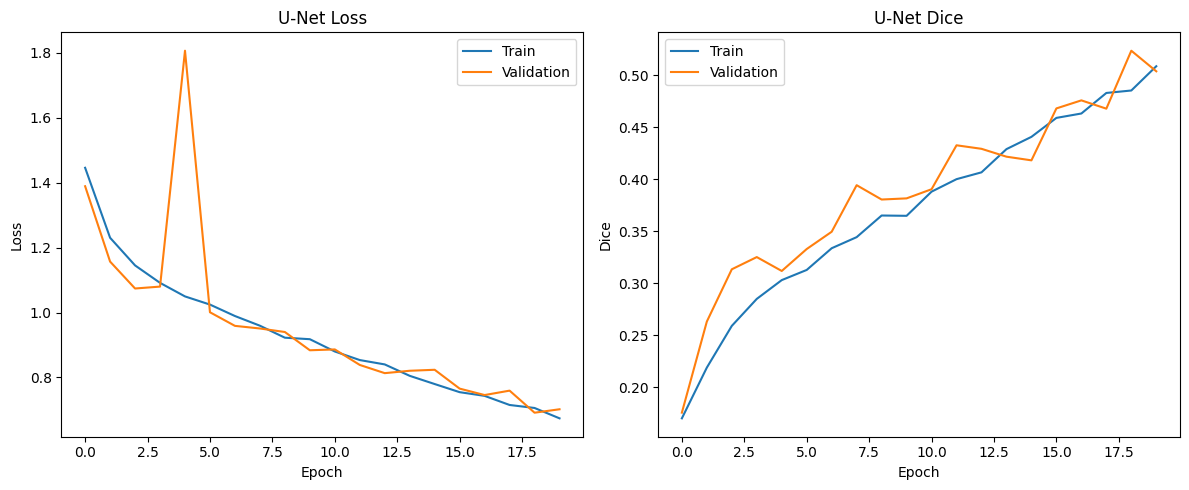

In [50]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(seg_history["train_loss"], label="Train")
plt.plot(seg_history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(seg_history["train_dice"], label="Train")
plt.plot(seg_history["val_dice"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("U-Net Dice")
plt.legend()

plt.tight_layout()
plt.show()

### Prediction

In [51]:
unet.load_state_dict(torch.load("/content/best_unet_busi.pth", map_location=device))
unet.eval()

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_si

In [52]:
images, masks = next(iter(seg_val_loader))

images = images.to(device)

with torch.no_grad():
    outputs = unet(images)

predictions = torch.sigmoid(outputs)
predictions = (predictions > 0.5).float()

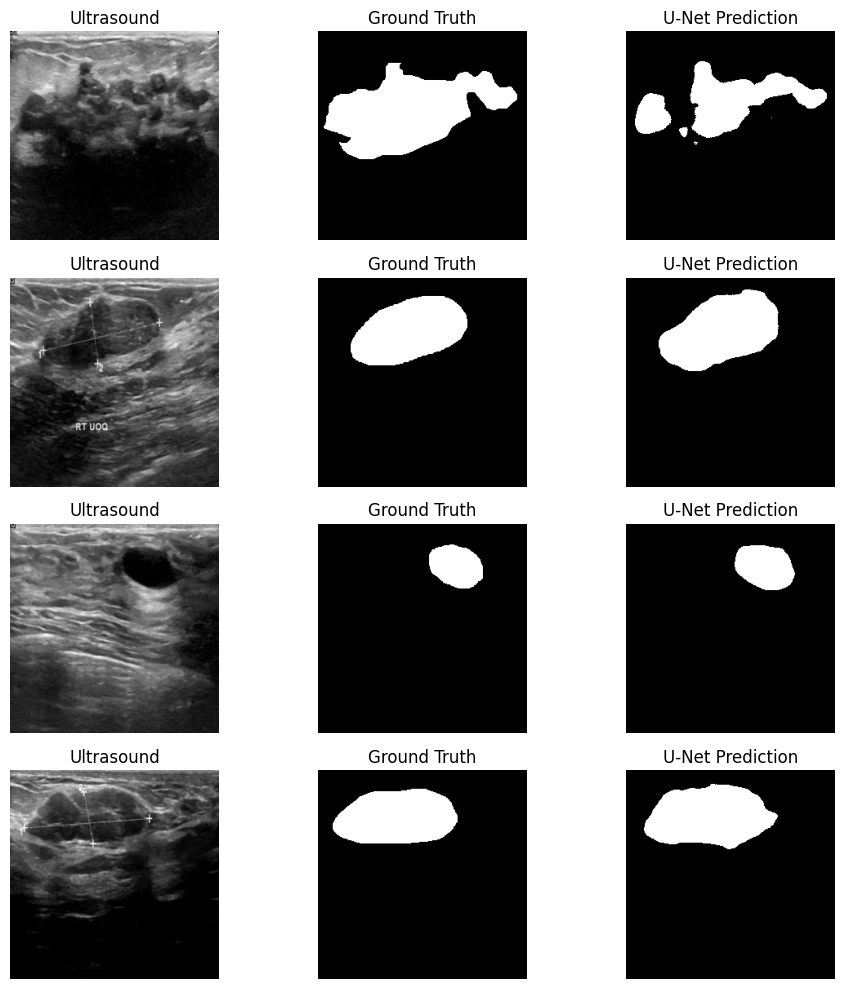

In [53]:
plt.figure(figsize=(10, 10))

for i in range(4):

    plt.subplot(4, 3, i * 3 + 1)
    plt.imshow(images[i][0].cpu(), cmap="gray")
    plt.title("Ultrasound")
    plt.axis("off")

    plt.subplot(4, 3, i * 3 + 2)
    plt.imshow(masks[i][0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(4, 3, i * 3 + 3)
    plt.imshow(predictions[i][0].cpu(), cmap="gray")
    plt.title("U-Net Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Evaluate Trained U-Net

In [54]:
unet.load_state_dict(torch.load("/content/best_unet_busi.pth", map_location=device))
unet.eval()

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_si

In [55]:
def iou_score(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    pred = pred.view(-1)

    target = target.view(-1)

    intersection = (pred * target).sum()

    union = (pred.sum() + target.sum() - intersection)
    iou = (intersection + smooth) / (union + smooth)

    return iou

### Evaluate on the Test Set

In [56]:
test_dice_scores = []
test_iou_scores = []

with torch.no_grad():
    for images, masks in seg_test_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = unet(images)

        dice = dice_coefficient(outputs, masks)
        iou = iou_score(outputs, masks)

        test_dice_scores.append(dice.item())
        test_iou_scores.append(iou.item())

test_dice = sum(test_dice_scores) / len(test_dice_scores)
test_iou = sum(test_iou_scores) / len(test_iou_scores)

print(f"Test Dice: {test_dice:.4f}")
print(f"Test IoU: {test_iou:.4f}")

Test Dice: 0.5123
Test IoU: 0.5763


In [57]:
test_results = []

with torch.no_grad():
    for images, masks in seg_test_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = unet(images)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities > 0.5).float()

        for i in range(images.size(0)):
            pred = predictions[i].view(-1)
            target = masks[i].view(-1)

            intersection = (pred * target).sum()

            dice = (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

            union = (pred.sum() + target.sum() - intersection)

            iou = (intersection + 1e-6) / (union + 1e-6)

            test_results.append({"dice": dice.item(), "iou": iou.item()})

seg_results_df = pd.DataFrame(test_results)
print(seg_results_df.describe())

               dice           iou
count  9.500000e+01  9.500000e+01
mean   6.638822e-01  5.527406e-01
std    2.733172e-01  2.803267e-01
min    1.080731e-10  1.080731e-10
25%    5.214270e-01  3.526692e-01
50%    7.586851e-01  6.111947e-01
75%    9.049856e-01  8.264603e-01
max    9.505911e-01  9.058348e-01


### Find Difficult Segmentation Cases

In [58]:
print(seg_results_df.sort_values("dice").head(10))

            dice           iou
92  1.080731e-10  1.080731e-10
50  1.553277e-10  1.553277e-10
70  2.204586e-10  2.204586e-10
23  3.396739e-10  3.396739e-10
3   7.986914e-02  4.159568e-02
13  8.083324e-02  4.211893e-02
58  9.180328e-02  4.810997e-02
10  1.194663e-01  6.352785e-02
71  2.419021e-01  1.375931e-01
42  2.662539e-01  1.535714e-01


### Visualize Test Predictions

In [59]:
images, masks = next(iter(seg_test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = unet(images_device)

predictions = (torch.sigmoid(outputs) > 0.5).float()

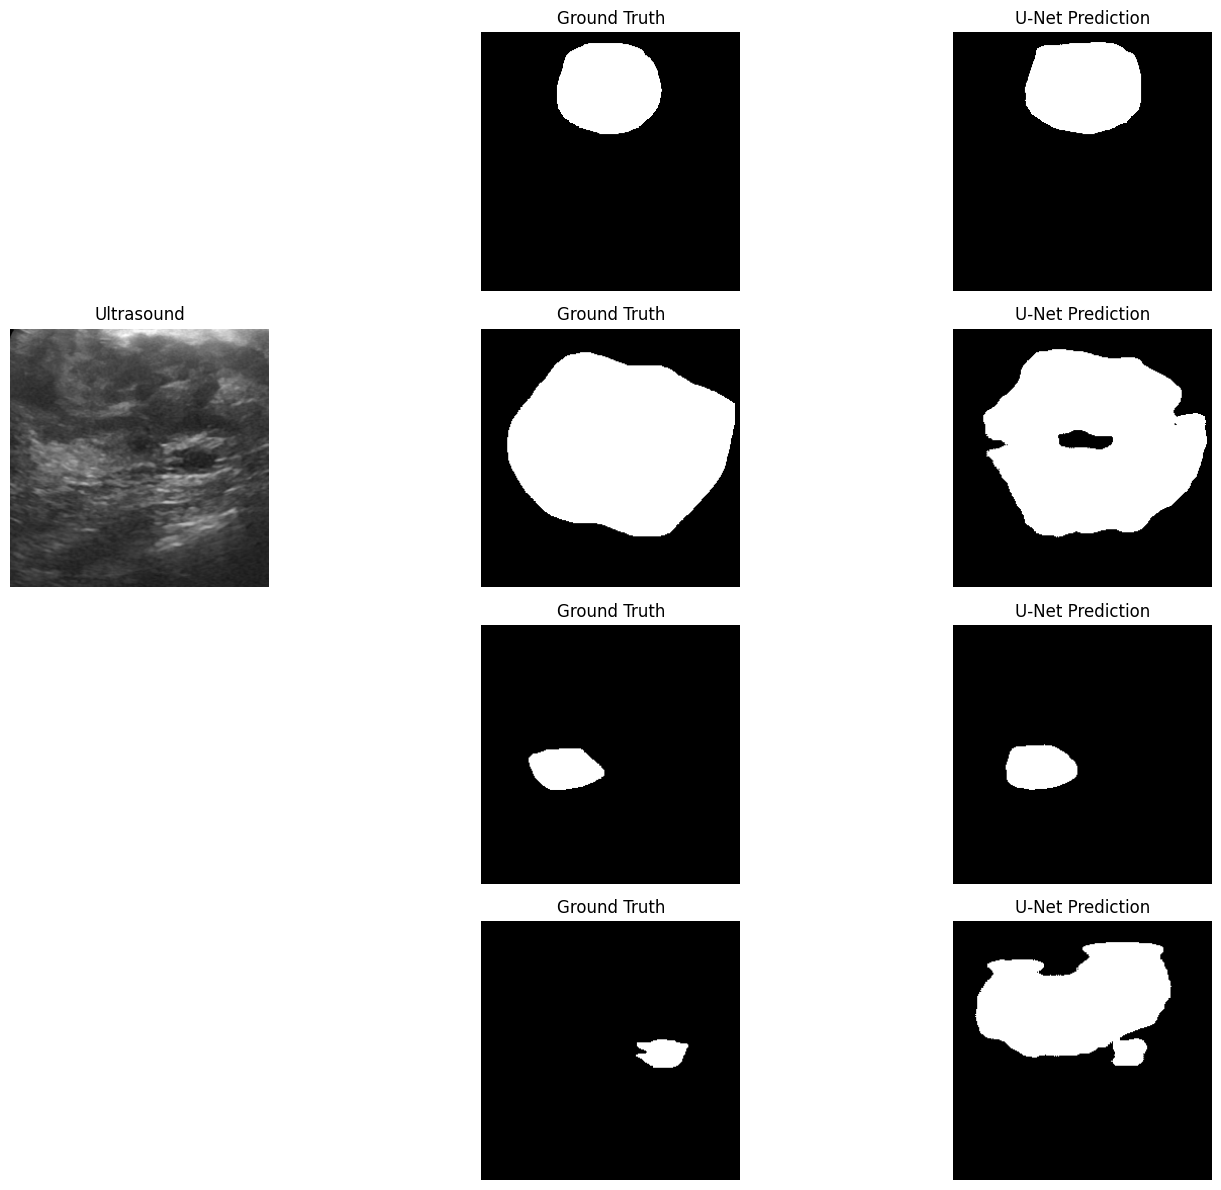

In [60]:
plt.figure(figsize=(15, 12))

for i in range(4):
    plt.subplot(4, 3, 1*3+1)
    plt.imshow(images[i][0], cmap="gray")

    plt.title("Ultrasound")
    plt.axis("off")

    plt.subplot(4, 3, i*3+2)
    plt.imshow(masks[i][0], cmap="gray")

    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(4, 3, i*3+3)
    plt.imshow(predictions[i][0].cpu(), cmap="gray")

    plt.title("U-Net Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

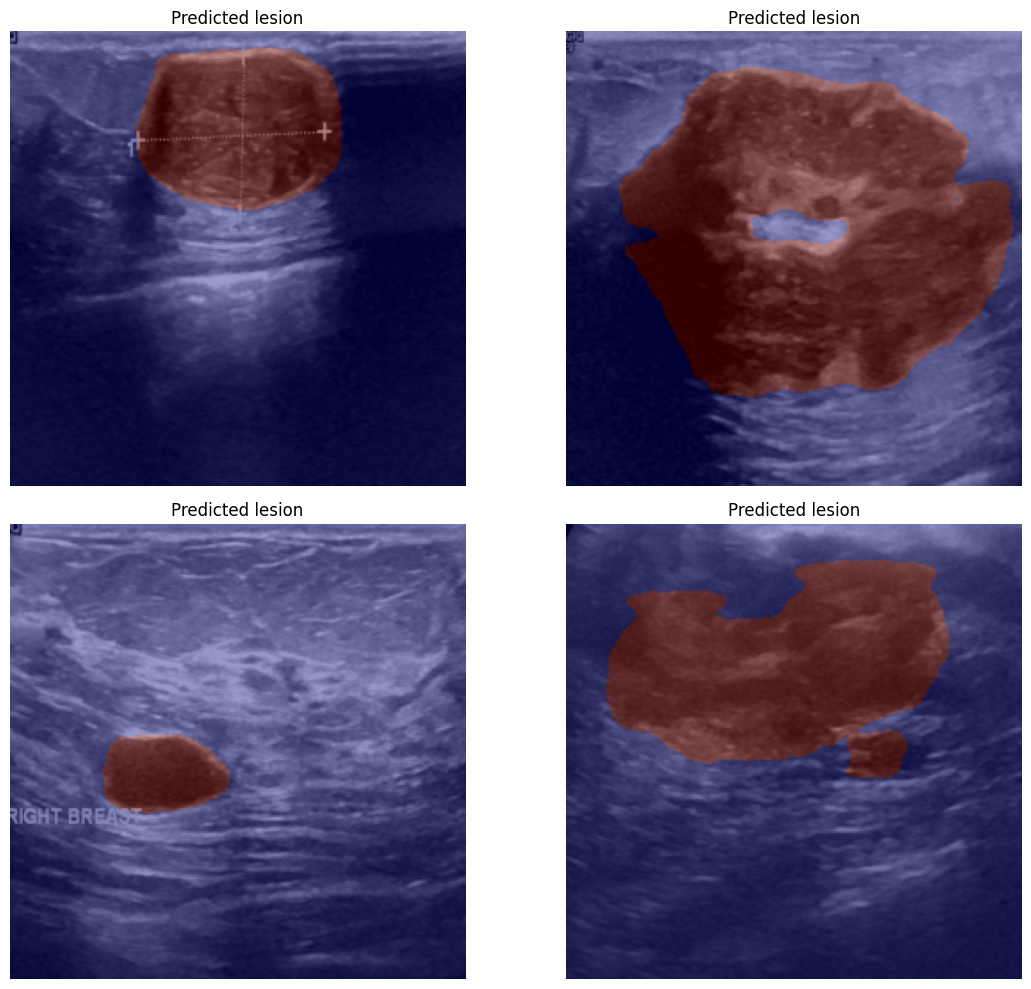

In [61]:
plt.figure(figsize=(12, 10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i][0], cmap="gray")

    plt.imshow(predictions[i][0].cpu(), cmap="jet", alpha=0.4)

    plt.title("Predicted lesion")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Save Segmentation Result

In [63]:
unet_results = {
    "model": "U-Net",
    "input_size": "256x256",
    "loss": "BCE + Dice Loss",
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "epochs": NUM_EPOCHS,
    "test_dice": test_dice,
    "test_iou": test_iou
}

print(unet_results)

{'model': 'U-Net', 'input_size': '256x256', 'loss': 'BCE + Dice Loss', 'optimizer': 'AdamW', 'learning_rate': 0.0001, 'epochs': 20, 'test_dice': 0.5122646888097128, 'test_iou': 0.5763284265995026}


## ROI-based Classification Experiment

In [64]:
unet.load_state_dict(torch.load("/content/best_unet_busi.pth"))
unet.eval()

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_si

In [65]:
def get_roi_from_mask(image, mask, padding=10):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return image

    x_min = max(0, xs.min() - padding)
    x_max = min(image.width, xs.max() + padding)

    y_min = max(0, ys.min() - padding)
    y_max = min(image.height, ys.max() + padding)

    roi = image.crop((x_min, y_min, x_max, y_max))

    return roi

In [68]:
filename = test_df.iloc[0]["filename"]

image_path = os.path.join(image_dir, filename)
image = Image.open(image_path).convert("L")

image_resized = image.resize((SEG_SIZE, SEG_SIZE), Image.BILINEAR)
image_array = np.array(image_resized).astype(np.float32) / 255.0

image_tensor = torch.tensor(image_array, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    output = unet(image_tensor)
    predicted_mask = (torch.sigmoid(output)[0, 0] > 0.5).cpu().numpy()

roi = get_roi_from_mask(image_resized, predicted_mask, padding=10)

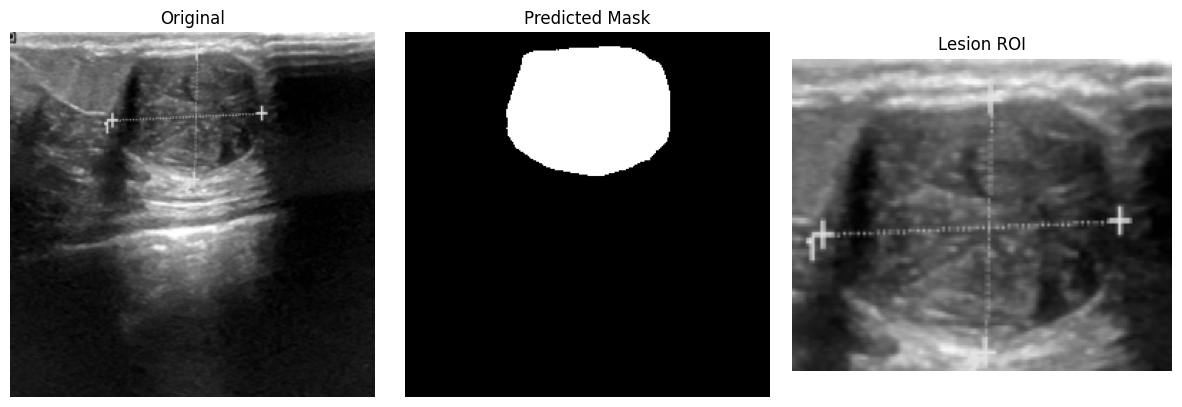

In [69]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_resized, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(predicted_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(roi, cmap="gray")
plt.title("Lesion ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

### ROI Dataset

In [70]:
class BUSIROIDataset(Dataset):
    def __init__(self, dataframe, image_dir, unet, device, transform=None, padding=10):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.unet = unet
        self.device = device
        self.transform = transform
        self.padding = padding

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        filename = row["filename"]
        label_name = row["label"]

        image_path = os.path.join(self.image_dir, filename)
        image = Image.open(image_path).convert("L")

        unet_image = image.resize((SEG_SIZE, SEG_SIZE), Image.BILINEAR)

        image_array = np.array(image_resized).astype(np.float32) / 255.0

        image_tensor = torch.tensor(image_array, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            output = unet(image_tensor)
            predicted_mask = (torch.sigmoid(output)[0, 0] > 0.5).cpu().numpy()

        roi = get_roi_from_mask(image_resized, predicted_mask, padding=10)

        roi = roi.convert("RGB")

        if self.transform:
            roi = self.transform(roi)

        label = 0 if label_name == "benign" else 1

        return roi, label

In [72]:
roi_train_dataset = BUSIROIDataset(train_df, image_dir, unet, device, transform=train_transform)
roi_val_dataset = BUSIROIDataset(val_df, image_dir, unet, device, transform=val_test_transform)
roi_test_dataset = BUSIROIDataset(test_df, image_dir, unet, device, transform=val_test_transform)

roi_train_loader = DataLoader(roi_train_dataset, batch_size=32, shuffle=True, num_workers=0)
roi_val_loader = DataLoader(roi_val_dataset, batch_size=32, shuffle=False, num_workers=0)
roi_test_loader = DataLoader(roi_test_dataset, batch_size=32, shuffle=False, num_workers=0)

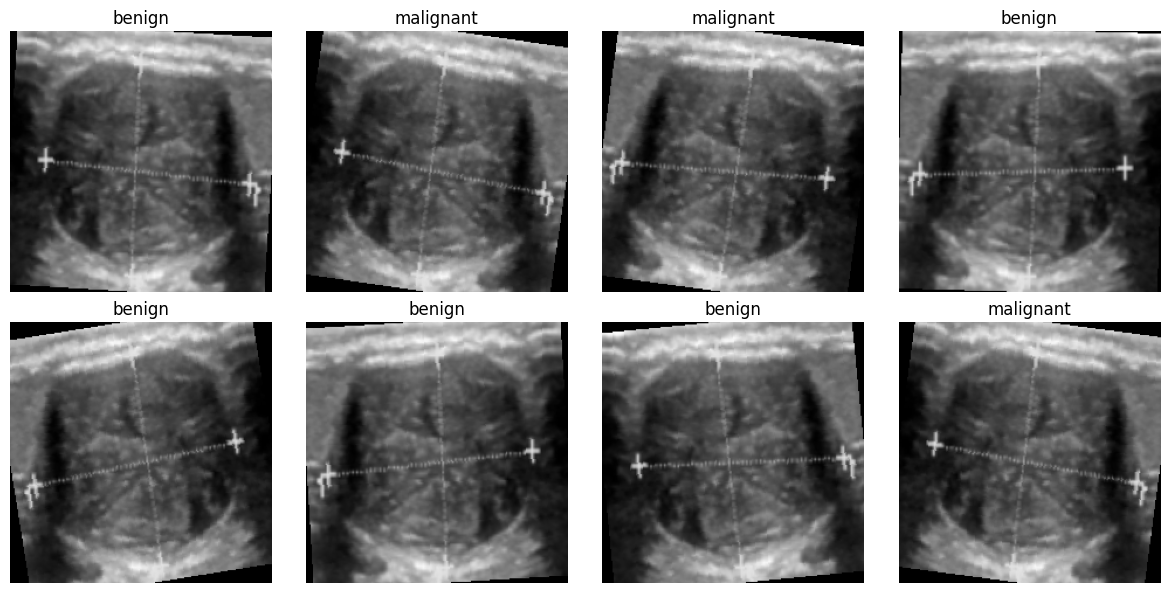

In [75]:
roi_images, roi_labels = next(iter(roi_train_loader))

plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i+1)

    image = roi_images[i]
    image = image * std + mean
    image = torch.clamp(image, 0, 1)
    image = image.permute(1, 2, 0)

    plt.imshow(image)

    label = "malignant" if roi_labels[i] == 1 else "benign"

    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()